<a href="https://colab.research.google.com/github/massimilianogasparini-author/creative-loop-dynamics/blob/main/phase_portrait.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

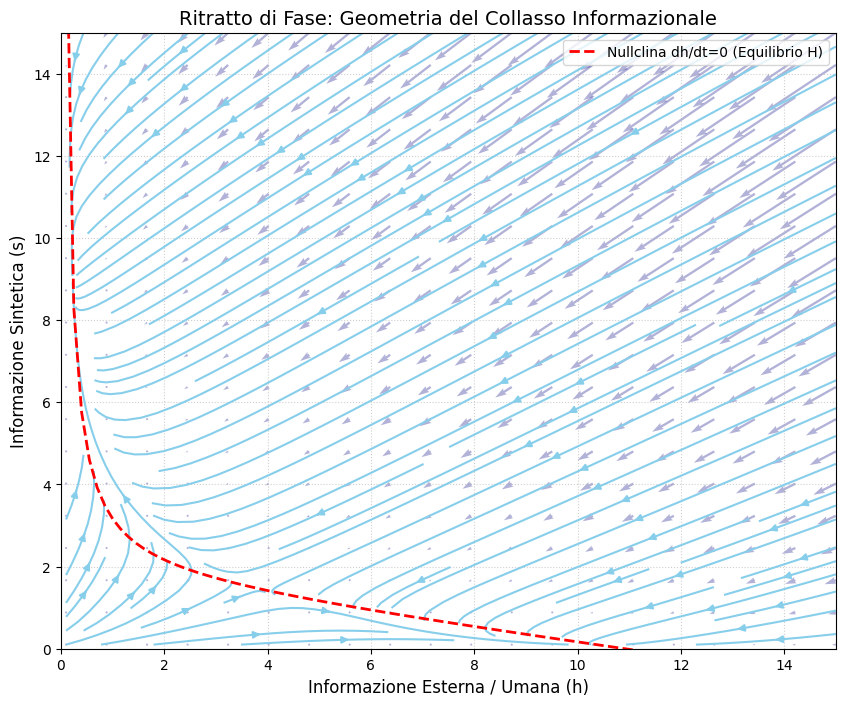

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parametri del sistema h-s (Sezione 4 del paper)
alpha, beta, gamma, lambd_, K, Ks = 0.5, 0.3, 0.4, 0.2, 10, 10
phi = 0.5 # Regime di bassa iniezione (Collasso)

def system(H, S):
    S_safe = np.maximum(S, 1e-6)
    dH = alpha * H * (1 - H/K) - beta * H * S + phi
    dS = gamma * S * np.log(Ks / S_safe) - lambd_ * S * H
    return dH, dS

# Creazione della griglia
h_range = np.linspace(0.1, 15, 20)
s_range = np.linspace(0.1, 15, 20)
H, S = np.meshgrid(h_range, s_range)

# Calcolo dei vettori
u, v = system(H, S)

# Plot corretto senza il parametro 'alpha' in streamplot
plt.figure(figsize=(10, 8))
plt.streamplot(H, S, u, v, color='skyblue', density=1.5) # Alpha rimosso qui
plt.quiver(H, S, u, v, color='navy', alpha=0.3)

# Nullclina dH/dt = 0
h_vals = np.linspace(0.1, 15, 100)
s_null = (alpha * (1 - h_vals/K) + phi/h_vals) / beta
plt.plot(h_vals, s_null, 'r--', label='Nullclina dh/dt=0 (Equilibrio H)', linewidth=2)

plt.title('Ritratto di Fase: Geometria del Collasso Informazionale', fontsize=14)
plt.xlabel('Informazione Esterna / Umana (h)', fontsize=12)
plt.ylabel('Informazione Sintetica (s)', fontsize=12)
plt.ylim(0, 15)
plt.xlim(0, 15)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()